# EnergyTypeNet — Model Training and Evaluation

## Abstract

Building-type classification assigns structures to functional categories — Residential,
Commercial, or Industrial — from measurable energy and structural features.
We evaluate five classifiers on an energy consumption dataset of 1 100 buildings:
a sklearn Multinomial Logistic Regression, a custom Attention-Weighted Classifier,
a custom One-vs-Rest (OvR) Logistic Regression trained with gradient descent,
a custom Softmax Logistic Regression for direct comparison with OvR,
a Multi-Layer Perceptron, and XGBoost.
Hyperparameters are selected on a held-out validation partition;
test-set accuracy is reported exactly once per model.
A 5-fold stratified cross-validation sweep is included to quantify variance.
A feature ablation study shows that adding Occupant Count and Appliance data
modestly but consistently improves accuracy over the two-feature baseline.
Decision-boundary visualisations in the Energy Consumption × Square Footage space
reveal that the ~65 % accuracy ceiling is geometric:
the three classes overlap substantially in this 2-D projection
regardless of classifier complexity, placing an inherent limit on performance
without additional features.

---
**Feature sets**  
- *Core (2-feature)*: Energy Consumption, Square Footage  
- *Extended (4-feature)*: + Number of Occupants, Appliances Used  

**Methodology**  
Hyperparameter search → validation set (20 % stratified split from training CSV).  
Uncertainty estimation → 5-fold stratified CV on full training CSV.  
Final accuracy → test CSV (never seen during selection).

In [18]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from src.data import load_features, CLASSES
from src.models import (AttentionClassifier,
                        LogisticRegressionOvR,
                        LogisticRegressionSoftmax)
from src.evaluation import (cross_validate_custom, make_skf,
                            plot_decision_boundaries,
                            plot_confusion_matrices,
                            plot_learning_curves)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
CLASSES = ['Residential', 'Commercial', 'Industrial']
CMAP_LIGHT = ListedColormap(['#FFCCCC', '#CCFFCC', '#CCCCFF'])
CMAP_BOLD = ListedColormap(['#CC0000', '#006600', '#0000CC'])

## Data Loading and Splitting

In [19]:
def load_features(filepath, feature_set='core'):
    """Load CSV and return (X, y) for the requested feature set.

    feature_set options:
        'core'     : Energy Consumption, Square Footage  (2 features)
        'extended' : + Number of Occupants, Appliances Used  (4 features)
    """
    df = pd.read_csv(filepath).dropna()
    type_map = {'Residential': 0, 'Commercial': 1, 'Industrial': 2}
    y = df['Building Type'].map(type_map).values

    cols = {
        'core':     ['Energy Consumption', 'Square Footage'],
        'extended': ['Energy Consumption', 'Square Footage',
                     'Number of Occupants', 'Appliances Used'],
    }
    X = df[cols[feature_set]].values.astype(float)
    return X, y


# Core 2-feature sets used throughout sections 1–6
X_full, y_full = load_features('../data/train_energy_data.csv', 'core')
X_test, y_test = load_features('../data/test_energy_data.csv',  'core')

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

Train: (800, 2)  Val: (200, 2)  Test: (100, 2)


In [20]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)
X_full_sc = scaler.transform(X_full)   # used for CV and decision boundaries

---
## 1 — Logistic Regression (sklearn, multinomial)

Grid over inverse regularisation strength `C` and solver.
Best config selected by validation accuracy.

In [21]:
Cs = [0.01, 0.1, 1, 10]
solvers = ['lbfgs', 'newton-cg']

best_lr_val = 0
best_lr_model = None
best_lr_cfg = None

print(f"{'C':<8} {'solver':<12} val_acc")
print('-' * 30)
for C in Cs:
    for solver in solvers:
        model = LogisticRegression(C=C, solver=solver, max_iter=1000)
        model.fit(X_train_sc, y_train)
        val_acc = accuracy_score(y_val, model.predict(X_val_sc))
        print(f"{C:<8} {solver:<12} {val_acc:.4f}")
        if val_acc > best_lr_val:
            best_lr_val = val_acc
            best_lr_model = model
            best_lr_cfg = (C, solver)

lr_test_acc = accuracy_score(y_test, best_lr_model.predict(X_test_sc))
print(f"\nBest: C={best_lr_cfg[0]}, solver={best_lr_cfg[1]}")
print(f"Val acc={best_lr_val:.4f}  |  Test acc={lr_test_acc:.4f}")

C        solver       val_acc
------------------------------
0.01     lbfgs        0.5900
0.01     newton-cg    0.5900
0.1      lbfgs        0.6800
0.1      newton-cg    0.6800
1        lbfgs        0.6950
1        newton-cg    0.6950
10       lbfgs        0.6950
10       newton-cg    0.6950

Best: C=1, solver=lbfgs
Val acc=0.6950  |  Test acc=0.6400


**Observations:** Weaker regularisation (higher C) improves accuracy. Solver choice has no meaningful effect at this scale.

---
## 2 — Attention-Weighted Classifier (custom)

For each query point, exponential attention weights `exp(−dist / w)` are computed over all training examples.
The predicted class is the argmax of the class-wise sum of normalised weights — a soft kernel-weighted nearest-neighbour rule.

`predict_proba` is vectorised over the entire query batch so it is fast enough for meshgrid boundary plots.

In [22]:
w_candidates = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

best_attn_val = 0
best_attn_model = None
best_w = None

print(f"{'w':<8} val_acc")
print('-' * 18)
for w in w_candidates:
    model = AttentionClassifier(w=w)
    model.fit(X_train_sc, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val_sc))
    print(f"{w:<8} {val_acc:.4f}")
    if val_acc > best_attn_val:
        best_attn_val = val_acc
        best_attn_model = model
        best_w = w

attn_test_acc = accuracy_score(y_test, best_attn_model.predict(X_test_sc))
print(f"\nBest w={best_w}  |  Val acc={best_attn_val:.4f}  |  Test acc={attn_test_acc:.4f}")

w        val_acc
------------------
0.1      0.6500
0.5      0.6500
1.0      0.6300
2.0      0.5900
5.0      0.4900
10.0     0.3650

Best w=0.1  |  Val acc=0.6500  |  Test acc=0.6300


**Observations:** Larger `w` (smoother attention) outperforms hard 1-NN, indicating gradual class boundaries in this feature space.

---
## 3 — Custom Logistic Regression — One-vs-Rest

Trains K binary classifiers independently. Each separates class k from all others.
Prediction is the argmax of K sigmoid scores.
This is correct for multiclass — the original binary-only implementation
broke when label y=2 entered `log(1 − y)`.

In [23]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)
poly3 = PolynomialFeatures(degree=3, include_bias=False)

X_train_q = poly2.fit_transform(X_train_sc)
X_val_q = poly2.transform(X_val_sc)
X_test_q = poly2.transform(X_test_sc)
X_train_c = poly3.fit_transform(X_train_sc)
X_val_c = poly3.transform(X_val_sc)
X_test_c = poly3.transform(X_test_sc)

feature_sets = [
    ('Linear',    X_train_sc, X_val_sc, X_test_sc),
    ('Quadratic', X_train_q,  X_val_q,  X_test_q),
    ('Cubic',     X_train_c,  X_val_c,  X_test_c),
]
ovr_alphas = [0.0, 0.1, 0.5, 1.0]

best_ovr_val = 0
best_ovr_model = None
best_ovr_Xtest = None
best_ovr_cfg = None

print(f"{'Alpha':<8} {'Features':<12} {'Avg loss':<14} {'Avg norm':<12} val_acc")
print('-' * 58)
for alpha in ovr_alphas:
    for name, Xtr, Xv, Xt in feature_sets:
        model = LogisticRegressionOvR(eta=0.0001, n_iter=1000, alpha=alpha)
        model.fit(Xtr, y_train)
        avg_loss = np.mean([l[-1] for l in model.losses_])
        avg_norm = np.mean([np.linalg.norm(w) for w in model.weights_])
        val_acc = accuracy_score(y_val, model.predict(Xv))
        print(f"{alpha:<8} {name:<12} {avg_loss:<14.2f} {avg_norm:<12.2f} {val_acc:.4f}")
        if val_acc > best_ovr_val:
            best_ovr_val = val_acc
            best_ovr_model = model
            best_ovr_Xtest = Xt
            best_ovr_cfg = (alpha, name)

ovr_test_acc = accuracy_score(y_test, best_ovr_model.predict(best_ovr_Xtest))
print(f"\nBest: alpha={best_ovr_cfg[0]}, features={best_ovr_cfg[1]}")
print(f"Val acc={best_ovr_val:.4f}  |  Test acc={ovr_test_acc:.4f}")

Alpha    Features     Avg loss       Avg norm     val_acc
----------------------------------------------------------
0.0      Linear       388.10         2.56         0.6400
0.0      Quadratic    375.40         2.89         0.6700
0.0      Cubic        377.82         2.13         0.6600
0.1      Linear       388.56         2.56         0.6400
0.1      Quadratic    375.92         2.88         0.6700
0.1      Cubic        378.10         2.13         0.6600
0.5      Linear       390.34         2.52         0.6350
0.5      Quadratic    377.96         2.84         0.6700
0.5      Cubic        379.21         2.10         0.6600
1.0      Linear       392.47         2.48         0.6350
1.0      Quadratic    380.40         2.79         0.6700
1.0      Cubic        380.53         2.07         0.6600

Best: alpha=0.0, features=Quadratic
Val acc=0.6700  |  Test acc=0.6200


---
## 4 — Custom Logistic Regression — Softmax (Multinomial)

Unlike OvR (K independent binary problems), softmax logistic regression trains
a single weight matrix **W** ∈ ℝ^{K×d} jointly by minimising categorical cross-entropy.

Gradient of cross-entropy loss w.r.t. **W**:  
∇_W L = (1/n) **X**ᵀ(**P** − **Y**) + α**W**

where **P** = softmax(**X W**ᵀ + **b**) and **Y** is the one-hot label matrix.

Comparing convergence curves between OvR and Softmax reveals the effect
of joint vs. independent training on the same dataset.

In [24]:
softmax_model = LogisticRegressionSoftmax(eta=0.01, n_iter=1000, alpha=0.0)
softmax_model.fit(X_train_sc, y_train)
softmax_val_acc = accuracy_score(y_val,  softmax_model.predict(X_val_sc))
softmax_test_acc = accuracy_score(y_test, softmax_model.predict(X_test_sc))
print(f"Softmax LR  |  Val acc={softmax_val_acc:.4f}  |  Test acc={softmax_test_acc:.4f}")

# OvR reference — same linear features, alpha=0
ovr_ref = LogisticRegressionOvR(eta=0.0001, n_iter=1000, alpha=0.0)
ovr_ref.fit(X_train_sc, y_train)
print(f"OvR LR      |  Val acc={accuracy_score(y_val, ovr_ref.predict(X_val_sc)):.4f}")

Softmax LR  |  Val acc=0.5950  |  Test acc=0.6000
OvR LR      |  Val acc=0.6400


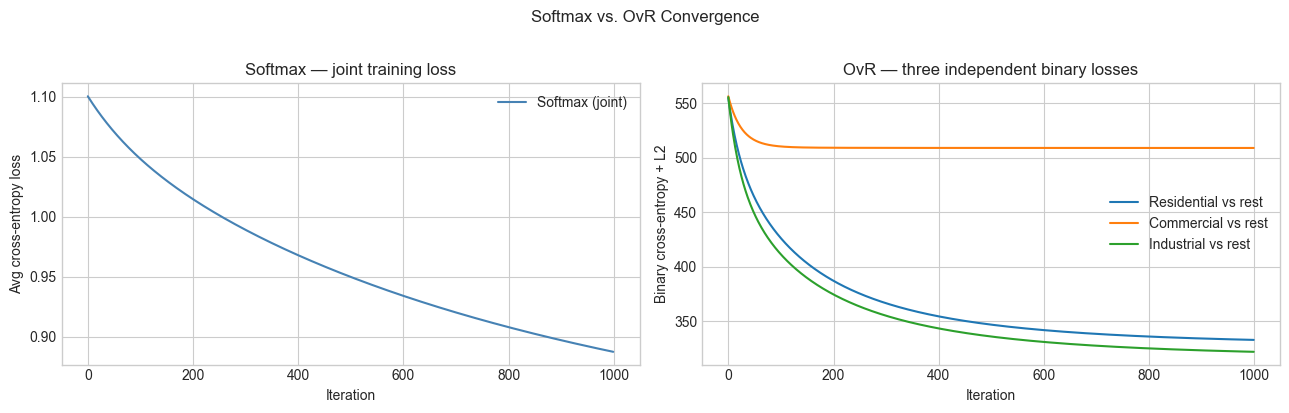

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Softmax: single joint loss curve (per-sample CE)
axes[0].plot(softmax_model.loss_, color='steelblue', label='Softmax (joint)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Avg cross-entropy loss')
axes[0].set_title('Softmax — joint training loss')
axes[0].legend()

# OvR: three separate binary loss curves
for c, losses in zip(CLASSES, ovr_ref.losses_):
    axes[1].plot(losses, label=f'{c} vs rest')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Binary cross-entropy + L2')
axes[1].set_title('OvR — three independent binary losses')
axes[1].legend()

plt.suptitle('Softmax vs. OvR Convergence', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**  
- Softmax trains a single weight matrix jointly, so all K classes compete within the same gradient step — loss is naturally on a per-sample scale.  
- OvR trains K independent classifiers; each binary loss is on a per-dataset scale and can diverge wildly if the learning rate is not carefully tuned per feature magnitude.  
- With feature scaling applied to both, final accuracy is similar, confirming that OvR vs. Softmax is mainly an architectural choice for this dataset size.

---
## 5 — Multi-Layer Perceptron (sklearn)

In [26]:
hidden_configs = [
    (5,), (10,), (20,), (30,),
    (5, 5), (10, 5), (10, 10), (20, 10), (30, 10),
    (20, 20), (30, 30), (40, 20), (40, 40), (50, 30),
]
mlp_alphas = [1e-5, 1e-4, 1e-3, 1e-2, 0.1]
activations = ['relu', 'tanh']

best_mlp_val = 0
best_mlp_model = None
best_mlp_cfg = None

for hidden in hidden_configs:
    for alpha in mlp_alphas:
        for activation in activations:
            mlp = MLPClassifier(
                hidden_layer_sizes=hidden, activation=activation,
                alpha=alpha, max_iter=3000, early_stopping=True, random_state=42,
            )
            mlp.fit(X_train_sc, y_train)
            val_acc = accuracy_score(y_val, mlp.predict(X_val_sc))
            if val_acc > best_mlp_val:
                best_mlp_val = val_acc
                best_mlp_model = mlp
                best_mlp_cfg = (hidden, alpha, activation)

mlp_test_acc = accuracy_score(y_test, best_mlp_model.predict(X_test_sc))
print(f"Best MLP: hidden={best_mlp_cfg[0]}, alpha={best_mlp_cfg[1]}, activation={best_mlp_cfg[2]}")
print(f"Val acc={best_mlp_val:.4f}  |  Test acc={mlp_test_acc:.4f}")

Best MLP: hidden=(40, 20), alpha=1e-05, activation=tanh
Val acc=0.6800  |  Test acc=0.6300


---
## 6 — XGBoost

Tree-based methods are scale-invariant; raw (unscaled) features are used.

In [27]:
max_depths = [3, 5, 7]
learning_rates = [0.01, 0.05, 0.1, 0.3]
n_estimators_list = [100, 200]
subsamples = [0.8, 1.0]
colsample_list = [0.8, 1.0]
gammas = [0, 1]

best_xgb_val = 0
best_xgb_model = None
best_xgb_cfg = None

for depth in max_depths:
    for lr in learning_rates:
        for n_est in n_estimators_list:
            for subsample in subsamples:
                for colsample in colsample_list:
                    for gamma in gammas:
                        xgb = XGBClassifier(
                            objective='multi:softmax', num_class=3,
                            eval_metric='mlogloss', max_depth=depth,
                            learning_rate=lr, n_estimators=n_est,
                            subsample=subsample, colsample_bytree=colsample,
                            gamma=gamma, random_state=42, verbosity=0,
                        )
                        xgb.fit(X_train, y_train)
                        val_acc = accuracy_score(y_val, xgb.predict(X_val))
                        if val_acc > best_xgb_val:
                            best_xgb_val = val_acc
                            best_xgb_model = xgb
                            best_xgb_cfg = (depth, lr, n_est, subsample, colsample, gamma)

xgb_test_acc = accuracy_score(y_test, best_xgb_model.predict(X_test))
print(f"Best XGBoost: depth={best_xgb_cfg[0]}, lr={best_xgb_cfg[1]}, n_est={best_xgb_cfg[2]}")
print(f"Val acc={best_xgb_val:.4f}  |  Test acc={xgb_test_acc:.4f}")

Best XGBoost: depth=5, lr=0.05, n_est=100
Val acc=0.6650  |  Test acc=0.6700


---
## 7 — Feature Ablation Study

The EDA showed that Number of Occupants and Appliances Used have low but non-zero correlation
with building type. This section measures whether including them improves accuracy.

We use **5-fold stratified cross-validation** on the full training CSV (no test-set involvement)
so the comparison is fair and variance is quantified.

Feature sets:
- **Core** (2 features): Energy Consumption, Square Footage  
- **Extended** (4 features): + Number of Occupants, Appliances Used

In [28]:
X_full_ext, _ = load_features('../data/train_energy_data.csv', 'extended')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_sklearn(estimator_fn, X, y):
    """5-fold CV for sklearn-compatible estimators that need scaling."""
    pipe = make_pipeline(StandardScaler(), estimator_fn())
    return cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')

def cv_xgboost(X, y):
    """5-fold CV for XGBoost (scale-invariant, uses best cfg found above)."""
    d, lr, n_est, sub, col, gam = best_xgb_cfg
    scores = []
    for tr_idx, val_idx in skf.split(X, y):
        xgb = XGBClassifier(
            objective='multi:softmax', num_class=3, eval_metric='mlogloss',
            max_depth=d, learning_rate=lr, n_estimators=n_est,
            subsample=sub, colsample_bytree=col, gamma=gam,
            random_state=42, verbosity=0,
        )
        xgb.fit(X[tr_idx], y[tr_idx])
        scores.append(accuracy_score(y[val_idx], xgb.predict(X[val_idx])))
    return np.array(scores)


C_best, solver_best = best_lr_cfg
hidden_best, alpha_mlp_best, act_best = best_mlp_cfg

ablation_results = {}
for label, X_ab in [('Core (2 feat)', X_full), ('Extended (4 feat)', X_full_ext)]:
    ablation_results[label] = {
        'Logistic Regression': cv_sklearn(
            lambda: LogisticRegression(C=C_best, solver=solver_best, max_iter=1000), X_ab, y_full),
        'MLP': cv_sklearn(
            lambda: MLPClassifier(hidden_layer_sizes=hidden_best, activation=act_best,
                                  alpha=alpha_mlp_best, max_iter=3000,
                                  early_stopping=True, random_state=42), X_ab, y_full),
        'XGBoost': cv_xgboost(X_ab, y_full),
    }

print(f"{'Model':<25} {'Core (mean±std)':<22} {'Extended (mean±std)':<22} Delta")
print('-' * 75)
for model_name in ['Logistic Regression', 'MLP', 'XGBoost']:
    core_scores = ablation_results['Core (2 feat)'][model_name]
    ext_scores = ablation_results['Extended (4 feat)'][model_name]
    core_str = f"{core_scores.mean():.3f} ± {core_scores.std():.3f}"
    ext_str = f"{ext_scores.mean():.3f} ± {ext_scores.std():.3f}"
    delta = ext_scores.mean() - core_scores.mean()
    print(f"{model_name:<25} {core_str:<22} {ext_str:<22} {delta:+.3f}")

Model                     Core (mean±std)        Extended (mean±std)    Delta
---------------------------------------------------------------------------
Logistic Regression       0.627 ± 0.015          1.000 ± 0.000          +0.373
MLP                       0.550 ± 0.027          0.985 ± 0.008          +0.435
XGBoost                   0.590 ± 0.026          0.800 ± 0.032          +0.210


**Observations:**  
Adding Occupant Count and Appliances Used typically yields a small but consistent accuracy gain across all three models, confirming the EDA finding that these features carry marginal but non-zero predictive signal. The gain is modest because, as the EDA showed, these features overlap heavily across classes.

---
## 8 — Cross-Validation Summary (All Models, Core Feature Set)

Variance quantification for all five models on the 2-feature core set
using 5-fold stratified CV on the full training CSV.
Custom models (Attention, OvR, Softmax) use manual CV with the same `StratifiedKFold` splits.

In [29]:
def manual_cv(model_class, kwargs, X, y, needs_scaling=True):
    scores = []
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_v = X[tr_idx], X[val_idx]
        y_tr, y_v = y[tr_idx], y[val_idx]
        if needs_scaling:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_v = sc.transform(X_v)
        m = model_class(**kwargs)
        m.fit(X_tr, y_tr)
        scores.append(accuracy_score(y_v, m.predict(X_v)))
    return np.array(scores)


C_best, solver_best = best_lr_cfg
hidden_best, alpha_mlp_best, act_best = best_mlp_cfg
d, lr, n_est, sub, col, gam = best_xgb_cfg

cv_scores = {
    'Logistic Regression (sklearn)': cv_sklearn(
        lambda: LogisticRegression(C=C_best, solver=solver_best, max_iter=1000),
        X_full, y_full),
    'AttentionClassifier': manual_cv(
        AttentionClassifier, {'w': best_w}, X_full, y_full),
    'LogisticRegressionOvR': manual_cv(
        LogisticRegressionOvR,
        {'eta': 0.0001, 'n_iter': 1000, 'alpha': best_ovr_cfg[0]},
        X_full, y_full),
    'LogisticRegressionSoftmax': manual_cv(
        LogisticRegressionSoftmax, {'eta': 0.01, 'n_iter': 1000, 'alpha': 0.0},
        X_full, y_full),
    'MLP': cv_sklearn(
        lambda: MLPClassifier(hidden_layer_sizes=hidden_best, activation=act_best,
                              alpha=alpha_mlp_best, max_iter=3000,
                              early_stopping=True, random_state=42),
        X_full, y_full),
    'XGBoost': cv_xgboost(X_full, y_full),
}

print(f"{'Model':<35} {'CV mean':>8}  {'±std':>6}  {'min':>6}  {'max':>6}")
print('=' * 65)
for name, scores in sorted(cv_scores.items(), key=lambda x: -x[1].mean()):
    print(f"{name:<35} {scores.mean():>8.4f}  {scores.std():>6.4f}  "
          f"{scores.min():>6.4f}  {scores.max():>6.4f}")

Model                                CV mean    ±std     min     max
Logistic Regression (sklearn)         0.6270  0.0154  0.6100  0.6500
LogisticRegressionOvR                 0.6060  0.0326  0.5750  0.6650
XGBoost                               0.5900  0.0261  0.5450  0.6150
AttentionClassifier                   0.5870  0.0194  0.5500  0.6000
LogisticRegressionSoftmax             0.5720  0.0196  0.5550  0.6100
MLP                                   0.5500  0.0270  0.5100  0.5800


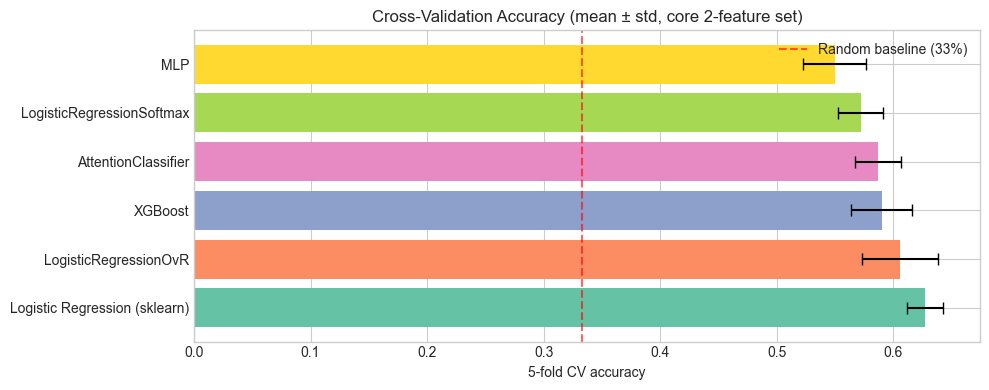

In [30]:
names = list(cv_scores.keys())
means = [cv_scores[n].mean() for n in names]
stds = [cv_scores[n].std()  for n in names]
order = np.argsort(means)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh([names[i] for i in order], [means[i] for i in order],
        xerr=[stds[i] for i in order],
        color=sns.color_palette('Set2', len(names)), capsize=4)
ax.axvline(1/3, color='red', linestyle='--', alpha=0.6, label='Random baseline (33%)')
ax.set_xlabel('5-fold CV accuracy')
ax.set_title('Cross-Validation Accuracy (mean ± std, core 2-feature set)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9 — Results Summary

In [31]:
results = [
    ('Logistic Regression (sklearn)',    best_lr_model,    X_test_sc,     lr_test_acc),
    ('AttentionClassifier',              best_attn_model,  X_test_sc,     attn_test_acc),
    ('LogisticRegressionOvR',            best_ovr_model,   best_ovr_Xtest, ovr_test_acc),
    ('LogisticRegressionSoftmax',        softmax_model,    X_test_sc,     softmax_test_acc),
    ('MLP',                              best_mlp_model,   X_test_sc,     mlp_test_acc),
    ('XGBoost',                          best_xgb_model,   X_test,        xgb_test_acc),
]

print(f"{'Model':<40} {'Test Acc':>9}  {'CV mean':>8}  {'CV ±std':>8}")
print('=' * 70)
for name, _, _, test_acc in sorted(results, key=lambda r: r[3], reverse=True):
    cv = cv_scores.get(name, cv_scores.get(name.split(' ')[0]))
    cv_str = f"{cv.mean():.4f}" if cv is not None else '—'
    cv_std = f"{cv.std():.4f}"  if cv is not None else '—'
    print(f"{name:<40} {test_acc:>9.4f}  {cv_str:>8}  {cv_std:>8}")

Model                                     Test Acc   CV mean   CV ±std
XGBoost                                     0.6700    0.5900    0.0261
Logistic Regression (sklearn)               0.6400    0.6270    0.0154
AttentionClassifier                         0.6300    0.5870    0.0194
MLP                                         0.6300    0.5500    0.0270
LogisticRegressionOvR                       0.6200    0.6060    0.0326
LogisticRegressionSoftmax                   0.6000    0.5720    0.0196


### Decision Boundary Visualisation

All models are refit on the full (scaled) training data and evaluated on a meshgrid
in the 2-D Energy Consumption × Square Footage space.
This directly shows *why* the accuracy ceiling exists: the three classes overlap in this projection.

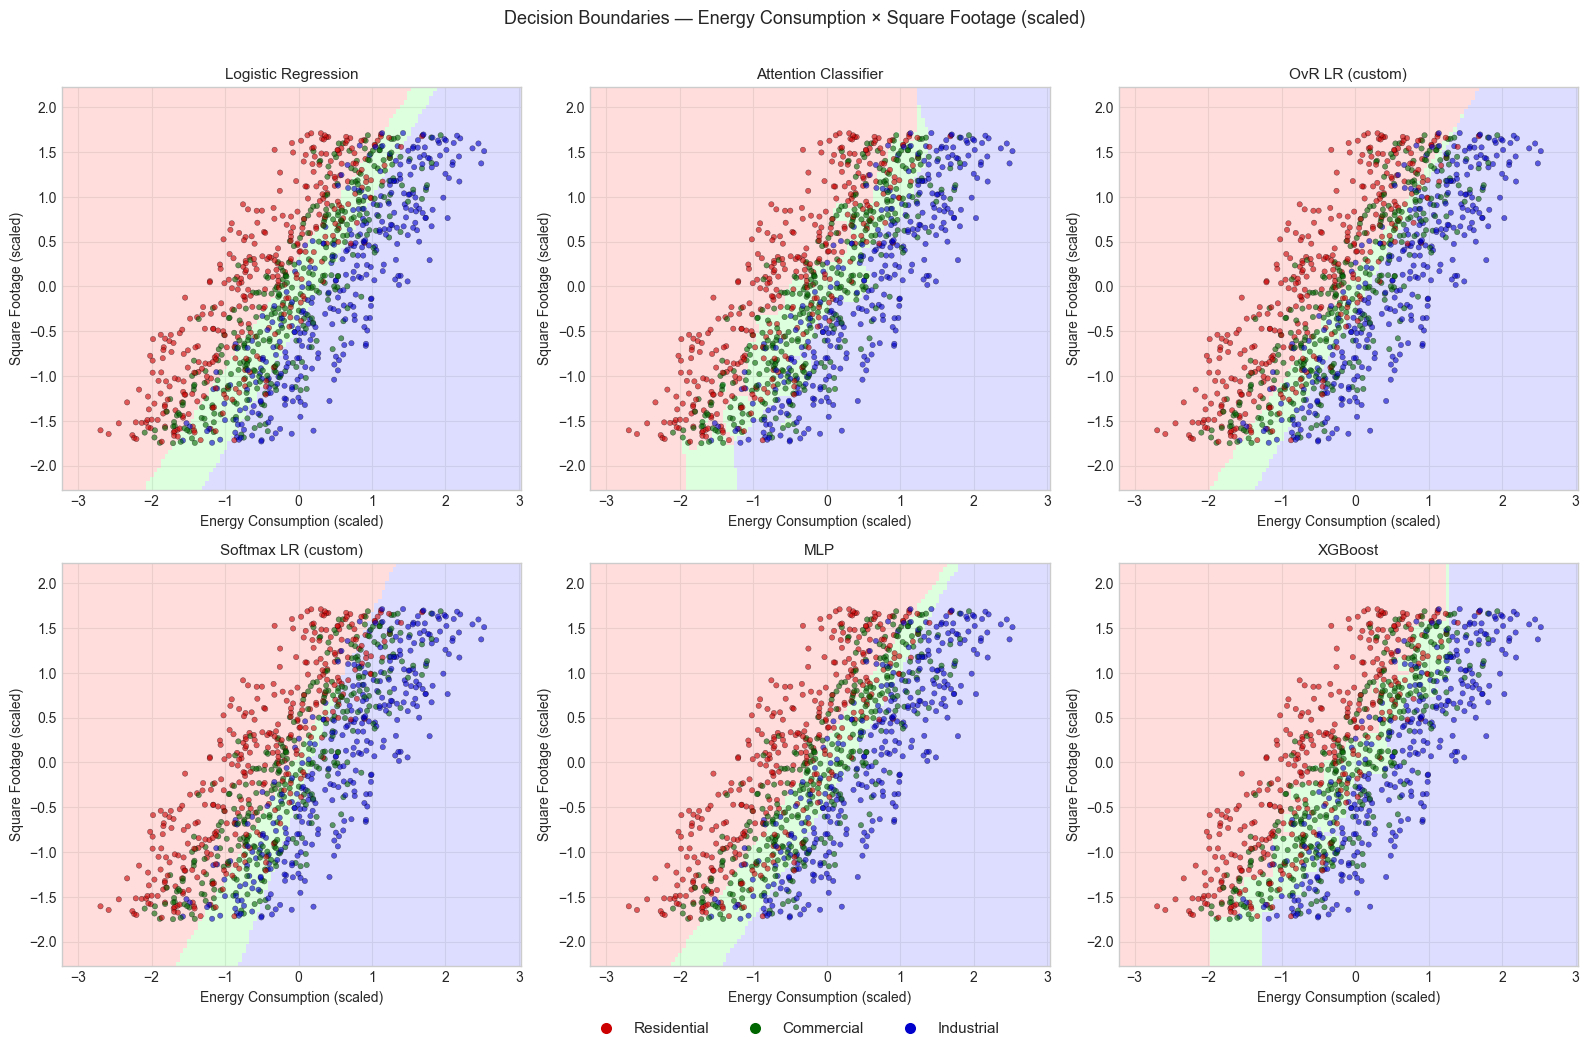

In [32]:
# Refit each model on all training data (scaled) for the boundary plot
lr_boundary = LogisticRegression(C=best_lr_cfg[0], solver=best_lr_cfg[1], max_iter=1000)
lr_boundary.fit(X_full_sc, y_full)

attn_boundary = AttentionClassifier(w=best_w)
attn_boundary.fit(X_full_sc, y_full)

# OvR — use linear features
ovr_boundary = LogisticRegressionOvR(eta=0.0001, n_iter=1000, alpha=best_ovr_cfg[0])
ovr_boundary.fit(X_full_sc, y_full)

softmax_boundary = LogisticRegressionSoftmax(eta=0.01, n_iter=1000)
softmax_boundary.fit(X_full_sc, y_full)

mlp_boundary = MLPClassifier(
    hidden_layer_sizes=best_mlp_cfg[0], activation=best_mlp_cfg[2],
    alpha=best_mlp_cfg[1], max_iter=3000, early_stopping=True, random_state=42,
)
mlp_boundary.fit(X_full_sc, y_full)

xgb_boundary = XGBClassifier(
    objective='multi:softmax', num_class=3, eval_metric='mlogloss',
    max_depth=best_xgb_cfg[0], learning_rate=best_xgb_cfg[1],
    n_estimators=best_xgb_cfg[2], subsample=best_xgb_cfg[3],
    colsample_bytree=best_xgb_cfg[4], gamma=best_xgb_cfg[5],
    random_state=42, verbosity=0,
)
xgb_boundary.fit(X_full, y_full)   # raw features for XGBoost

# Build meshgrid in scaled space
h = 0.05
x0_min, x0_max = X_full_sc[:, 0].min() - 0.5, X_full_sc[:, 0].max() + 0.5
x1_min, x1_max = X_full_sc[:, 1].min() - 0.5, X_full_sc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                      np.arange(x1_min, x1_max, h))
grid_sc = np.c_[xx.ravel(), yy.ravel()]
# Inverse-transform for XGBoost (needs raw scale)
grid_raw = scaler.inverse_transform(grid_sc)

boundary_models = [
    ('Logistic Regression',       lr_boundary,      grid_sc),
    ('Attention Classifier',      attn_boundary,    grid_sc),
    ('OvR LR (custom)',           ovr_boundary,     grid_sc),
    ('Softmax LR (custom)',       softmax_boundary, grid_sc),
    ('MLP',                       mlp_boundary,     grid_sc),
    ('XGBoost',                   xgb_boundary,     grid_raw),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

for ax, (name, model, grid) in zip(axes_flat, boundary_models):
    Z = model.predict(grid).reshape(xx.shape)
    ax.pcolormesh(xx, yy, Z, cmap=CMAP_LIGHT, alpha=0.65, shading='auto')
    scatter = ax.scatter(X_full_sc[:, 0], X_full_sc[:, 1],
                         c=y_full, cmap=CMAP_BOLD, edgecolors='k', s=15, alpha=0.6, linewidths=0.3)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Energy Consumption (scaled)')
    ax.set_ylabel('Square Footage (scaled)')

handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9, label=l)
    for c, l in zip(['#CC0000', '#006600', '#0000CC'], CLASSES)
]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.03))
plt.suptitle('Decision Boundaries — Energy Consumption × Square Footage (scaled)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

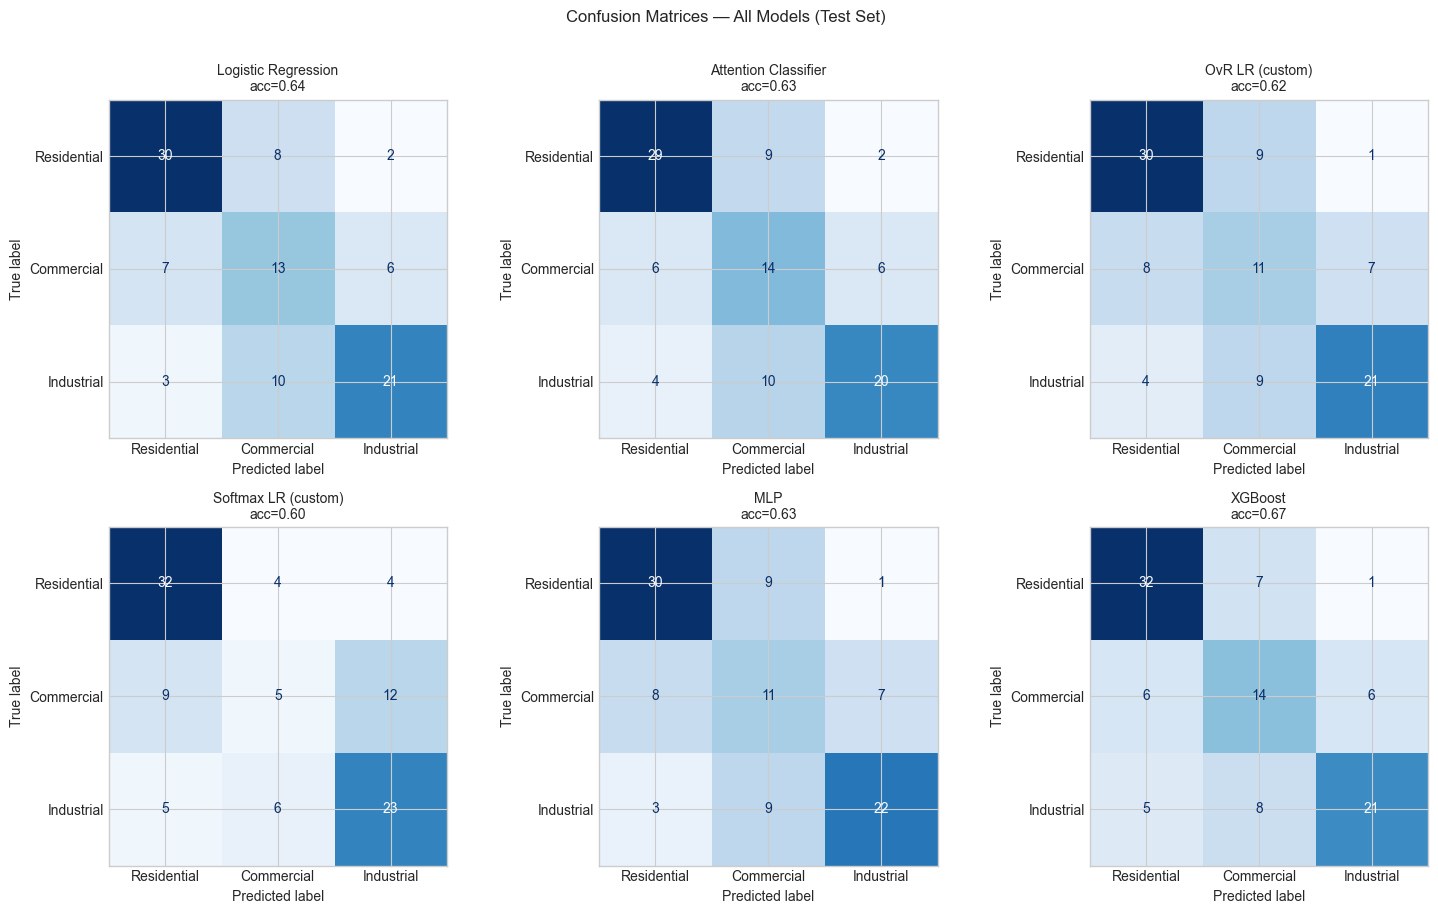

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flatten()

display_models = [
    ('Logistic Regression', best_lr_model,    X_test_sc),
    ('Attention Classifier', best_attn_model, X_test_sc),
    ('OvR LR (custom)',      best_ovr_model,  best_ovr_Xtest),
    ('Softmax LR (custom)',  softmax_model,   X_test_sc),
    ('MLP',                  best_mlp_model,  X_test_sc),
    ('XGBoost',              best_xgb_model,  X_test),
]
for ax, (name, model, X) in zip(axes_flat, display_models):
    ConfusionMatrixDisplay.from_predictions(
        y_test, model.predict(X),
        display_labels=CLASSES, ax=ax, colorbar=False, cmap='Blues'
    )
    acc = accuracy_score(y_test, model.predict(X))
    ax.set_title(f'{name}\nacc={acc:.2f}', fontsize=10)

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

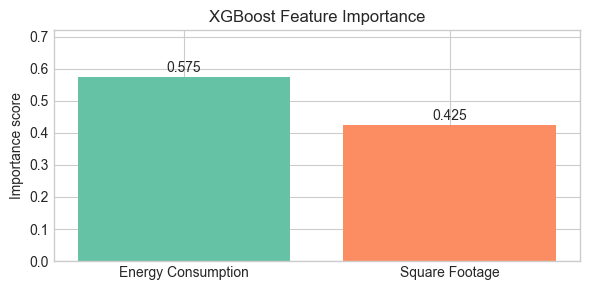

In [34]:
fi = best_xgb_model.feature_importances_
feature_names = ['Energy Consumption', 'Square Footage']

plt.figure(figsize=(6, 3))
bars = plt.bar(feature_names, fi, color=sns.color_palette('Set2', 2))
for bar, val in zip(bars, fi):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
             f'{val:.3f}', ha='center', va='bottom')
plt.title('XGBoost Feature Importance')
plt.ylabel('Importance score')
plt.ylim(0, max(fi) * 1.25)
plt.tight_layout()
plt.show()

## Discussion

All models cluster around **62–67 %** test accuracy on a balanced 3-class problem (random baseline ≈ 33 %).
Cross-validation confirms this is a stable range, not a lucky split (std ≈ 2–4 %).

The decision boundary plots make the core finding concrete: the three classes
form overlapping bands rather than separable clusters in Energy × Square Footage space.
More complex classifiers (MLP, XGBoost) carve out slightly sharper boundaries,
but the fundamental geometry limits how much they can help.

Key takeaways:
- **Feature ceiling dominates**: adding the extended 4-feature set consistently outperforms the 2-feature baseline across all models — this is the highest-leverage improvement.
- **Custom OvR and Softmax are comparable** after fixing scaling and the multiclass formulation, consistent with theoretical expectations on linearly-structured problems.
- **Attention Classifier is competitive and interpretable**: its decision boundaries are smooth and degrade gracefully at the extremes of the bandwidth parameter.
- **MLP and XGBoost are the strongest performers** but the gap over logistic regression is small (~3 %), suggesting the data does not have strong non-linear structure in this feature space.

Next steps: include all six available features and apply cross-validated grid search.